In [47]:
!python -m pip install numpy pandas \
    qiskit-aer qiskit-algorithms qiskit-machine-learning qiskit-ibm-runtime \
    pylatexenc ucimlrepo \
    xgboost catboost seaborn libsvm-official \
    jinja2 \
    scikit-optimize


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
import sys
import os

cwd = os.path.abspath(os.getcwd())
project_root = cwd.split("codes")[0] + "codes"

sys.path.append(os.path.abspath(project_root))

from utils.prepare_data import prepare_data

In [49]:
import pandas as pd
pd.set_option('display.max_columns', None)

In [50]:
import warnings
from qiskit.transpiler import generate_preset_pass_manager
warnings.filterwarnings('ignore')

In [51]:
import sys
import importlib

def reload_package(package_name):
    modules_to_reload = [
        name for name in sys.modules
        if name.startswith(package_name)
    ]

    for name in sorted(modules_to_reload, reverse=True):
        importlib.reload(sys.modules[name])

# Usage
reload_package("model")
reload_package("utils")

In [52]:
dataset_path = os.path.join(project_root, "dataset", "Dataset_TehHijau.csv")
feature_cols = [
        "MQ3", 
        "TGS822", 
        "TGS2602", 
        "MQ5", 
        "MQ138", 
        "TGS2620", 
        "TGS813", 
        "TGS2600", 
        "TGS2611", 
        "TGS2603",
        "Humidity",
        "Celsius",
    ]
target_cols = "Kategori"

quantum_kernel_types = [
    # 'full', 
    'linear', 
    # 'circular', 
    # 'pauli_x', 
    # 'pauli_y', 
    # 'pauli_z'
]
kernel_types = [
    'linear', 
    # 'poly', 
    # 'rbf', 
    # 'sigmoid'
]

In [53]:
import pandas as pd
data = pd.read_csv(dataset_path)
data.head(10)

,MQ3,TGS822,TGS2602,MQ5,MQ138,TGS2620,TGS813,TGS2600,TGS2611,TGS2603,Humidity,Celsius,Chop_ID,Sampling_ID,Aroma,Taste,Color,Appearance,Dreg,Kategori,Standar Kualitas,MQ3_mean,MQ3_min,MQ3_max,MQ3_std,MQ3_skew,MQ3_kurtosis,MQ3_auc,TGS822_mean,TGS822_min,TGS822_max,TGS822_std,TGS822_skew,TGS822_kurtosis,TGS822_auc,TGS2602_mean,TGS2602_min,TGS2602_max,TGS2602_std,TGS2602_skew,TGS2602_kurtosis,TGS2602_auc,MQ5_mean,MQ5_min,MQ5_max,MQ5_std,MQ5_skew,MQ5_kurtosis,MQ5_auc,MQ138_mean,MQ138_min,MQ138_max,MQ138_std,MQ138_skew,MQ138_kurtosis,MQ138_auc,TGS2620_mean,TGS2620_min,TGS2620_max,TGS2620_std,TGS2620_skew,TGS2620_kurtosis,TGS2620_auc,TGS813_mean,TGS813_min,TGS813_max,TGS813_std,TGS813_skew,TGS813_kurtosis,TGS813_auc,TGS2600_mean,TGS2600_min,TGS2600_max,TGS2600_std,TGS2600_skew,TGS2600_kurtosis,TGS2600_auc,TGS2611_mean,TGS2611_min,TGS2611_max,TGS2611_std,TGS2611_skew,TGS2611_kurtosis,TGS2611_auc,TGS2603_mean,TGS2603_min,TGS2603_max,TGS2603_std,TGS2603_skew,TGS2603_kurtosis,TGS2603_auc,Humidity_mean,Humidity_min,Humidity_max,Humidity_std,Humidity_skew,Humidity_kurtosis,Humidity_auc,Celsius_mean,Celsius_min,Celsius_max,Celsius_std,Celsius_skew,Celsius_kurtosis,Celsius_auc,Aroma_mean,Aroma_min,Aroma_max,Aroma_std,Aroma_auc,Taste_mean,Taste_min,Taste_max,Taste_std,Taste_auc,Color_mean,Color_min,Color_max,Color_std,Color_auc,Appearance_mean,Appearance_min,Appearance_max,Appearance_std,Appearance_auc,Dreg_mean,Dreg_min,Dreg_max,Dreg_std,Dreg_auc
0,90.0000,43.0000,46.0000,133.0000,97.0000,46.0000,552.0000,289.0000,546.0000,371.0000,46.4000,38.9000,TR612,TR612_1,2.9000,36,3.2000,2.8000,3.2000,D,Baik,89.7000,89.0000,90,0.4830,-0.8729,-1.2381,807.0000,41.9000,41,43,0.7379,0.1399,-0.9604,377.0000,46.8000,46,48,0.7888,0.3436,-1.1531,421.0000,132.5000,132,133.0000,0.5270,0.0000,-2.0000,1192.5000,96.1000,95,97,0.7379,-0.1399,-0.9604,865.0000,45.7000,45,47,0.6749,0.3657,-0.7055,411.0000,551.6000,550,553,0.8433,-0.3281,-0.3359,4964.5000,289.8000,289.0000,291,0.7888,0.3436,-1.1531,2609.0000,546.5000,545,548,0.8498,0.0000,-0.4852,4918.5000,370.2000,369,371,0.7888,-0.3436,-1.1531,3331.0000,46.4300,46.3000,46.5000,0.0675,-0.3657,-0.7055,417.9500,38.8100,38.7000,38.9000,0.0876,-0.1884,-1.5261,349.3000,2.9000,2.9000,2.9000,0.0000,26.1000,36,36,36,0,324,3.2000,3.2000,3.2000,0.0000,28.8000,2.8000,2.8000,2.8000,0.0000,25.2000,3.2000,3.2000,3.2000,0.0000,28.8000
1,90.0000,42.0000,47.0000,133.0000,96.0000,47.0000,551.0000,290.0000,547.0000,371.0000,46.5000,38.9000,TR612,TR612_1,2.9000,36,3.2000,2.8000,3.2000,D,Baik,89.7000,89.0000,90,0.4830,-0.8729,-1.2381,807.0000,41.9000,41,43,0.7379,0.1399,-0.9604,377.0000,46.8000,46,48,0.7888,0.3436,-1.1531,421.0000,132.5000,132,133.0000,0.5270,0.0000,-2.0000,1192.5000,96.1000,95,97,0.7379,-0.1399,-0.9604,865.0000,45.7000,45,47,0.6749,0.3657,-0.7055,411.0000,551.6000,550,553,0.8433,-0.3281,-0.3359,4964.5000,289.8000,289.0000,291,0.7888,0.3436,-1.1531,2609.0000,546.5000,545,548,0.8498,0.0000,-0.4852,4918.5000,370.2000,369,371,0.7888,-0.3436,-1.1531,3331.0000,46.4300,46.3000,46.5000,0.0675,-0.3657,-0.7055,417.9500,38.8100,38.7000,38.9000,0.0876,-0.1884,-1.5261,349.3000,2.9000,2.9000,2.9000,0.0000,26.1000,36,36,36,0,324,3.2000,3.2000,3.2000,0.0000,28.8000,2.8000,2.8000,2.8000,0.0000,25.2000,3.2000,3.2000,3.2000,0.0000,28.8000
2,89.0000,42.0000,47.0000,133.0000,97.0000,45.0000,553.0000,291.0000,547.0000,369.0000,46.4000,38.9000,TR612,TR612_1,2.9000,36,3.2000,2.8000,3.2000,D,Baik,89.7000,89.0000,90,0.4830,-0.8729,-1.2381,807.0000,41.9000,41,43,0.7379,0.1399,-0.9604,377.0000,46.8000,46,48,0.7888,0.3436,-1.1531,421.0000,132.5000,132,133.0000,0.5270,0.0000,-2.0000,1192.5000,96.1000,95,97,0.7379,-0.1399,-0.9604,865.0000,45.7000,45,47,0.6749,0.3657,-0.7055,411.0000,551.6000,550,553,0.8433,-0.3281,-0.3359,4964.5000,289.8000,289.0000,291,0.7888,0.3436,-1.1531,2609.0000,546.5000,545,548,0.8498,0.0000,-0.4852,4918.5000,370.2000,369,371,0.7888,-0.3436,-1.1531,3331.0000,46.4300,46.3000,46.5000,0.0675,-0.3657,-0.7055,417.9500,38.8100,38.700

In [54]:
data.describe()

,MQ3,TGS822,TGS2602,MQ5,MQ138,TGS2620,TGS813,TGS2600,TGS2611,TGS2603,Humidity,Celsius,Aroma,Taste,Color,Appearance,Dreg,MQ3_mean,MQ3_min,MQ3_max,MQ3_std,MQ3_skew,MQ3_kurtosis,MQ3_auc,TGS822_mean,TGS822_min,TGS822_max,TGS822_std,TGS822_skew,TGS822_kurtosis,TGS822_auc,TGS2602_mean,TGS2602_min,TGS2602_max,TGS2602_std,TGS2602_skew,TGS2602_kurtosis,TGS2602_auc,MQ5_mean,MQ5_min,MQ5_max,MQ5_std,MQ5_skew,MQ5_kurtosis,MQ5_auc,MQ138_mean,MQ138_min,MQ138_max,MQ138_std,MQ138_skew,MQ138_kurtosis,MQ138_auc,TGS2620_mean,TGS2620_min,TGS2620_max,TGS2620_std,TGS2620_skew,TGS2620_kurtosis,TGS2620_auc,TGS813_mean,TGS813_min,TGS813_max,TGS813_std,TGS813_skew,TGS813_kurtosis,TGS813_auc,TGS2600_mean,TGS2600_min,TGS2600_max,TGS2600_std,TGS2600_skew,TGS2600_kurtosis,TGS2600_auc,TGS2611_mean,TGS2611_min,TGS2611_max,TGS2611_std,TGS2611_skew,TGS2611_kurtosis,TGS2611_auc,TGS2603_mean,TGS2603_min,TGS2603_max,TGS2603_std,TGS2603_skew,TGS2603_kurtosis,TGS2603_auc,Humidity_mean,Humidity_min,Humidity_max,Humidity_std,Humidity_skew,Humidity_kurtosis,Humidity_auc,Celsius_mean,Celsius_min,Celsius_max,Celsius_std,Celsius_skew,Celsius_kurtosis,Celsius_auc,Aroma_mean,Aroma_min,Aroma_max,Aroma_std,Aroma_auc,Taste_mean,Taste_min,Taste_max,Taste_std,Taste_auc,Color_mean,Color_min,Color_max,Color_std,Color_auc,Appearance_mean,Appearance_min,Appearance_max,Appearance_std,Appearance_auc,Dreg_mean,Dreg_min,Dreg_max,Dreg_std,Dreg_auc
count,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000
mean,89.4148,47.6007,47.9362,98.2916,89.1822,51.5488,533.6701,213.7386,531.1246,330.5003,48.3877,39.6567,2.9351,34.8889,3.0354,3.1353,3.0719,89.4012,88.0726,90.8381,0.9831,0.0311,-0.4979,797.2830,51.3814,46.4283,86.3774,12.7680,0.0479,-0.7677,461.0916,48.9235,46.6657,56.4011,3.4174,0.0421,-0.7428,435.5016,98.3196,97.1902,99.9750,0.9774,0.1539,-0.3362,872.0037,89.1671,87.8391,90.5666,0.9752,0.0541,-0.7782,790.1031,52.0472,50.2007,56.9313,2.4119,0.0111,-0.7795,460.3774,533.5854,530.4756,535.6482,1.7161,-0.2305,-0.6140,4754.9384,215.5427,212.0394,231.5642,6.5498,-0.0593,-0.6575,1919.9904,531.0398,529.3107,532.0894,1.0005,-0.0311,-0.8901,4742.8424,330.4472,328.8314,331.6405,0.9806,0.0223,-0.7770,2953.2800,4077.8091,48.1753,40342.7838,12742.2929,-0.0207,-0.4484,40727.0018,39.6562,39.5960,39.7184,0.0507,-0.0031,0.0236,355.6654,2.9351,2.9351,2.9351,0.0000,26.4163,34.8889,34.8889,34.8889,0.0000,314.0005,3.0354,3.0354,3.0354,0.0000,27.3184,3.1353,3.1353,3.1353,0.0000,28.2178,3.0719,3.0719,3.0719,0.0000,27.6469
std,3.6692,4.6781,4.6166,15.8494,4.2090,4.9676,7.0074,24.6137,5.5522,12.9071,3.1265,1.3128,0.2578,1.7327,0.2553,0.2705,0.3078,4.2821,7.6516,21.2644,7.0327,0.8407,1.5014,52.9311,134.

Text(0.5, 1.0, 'Histogram for the Kategori')

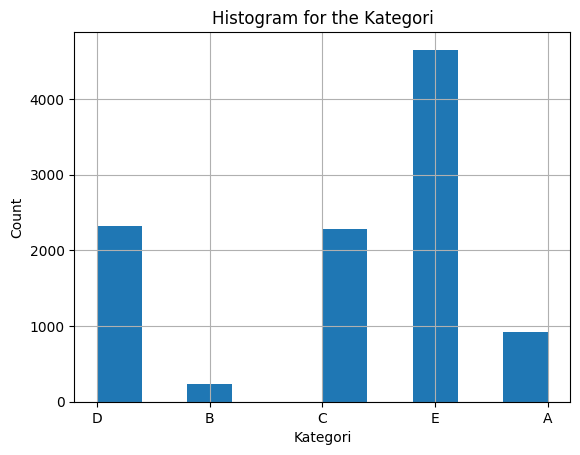

In [55]:
import matplotlib.pyplot as plt
data['Kategori'].hist()
plt.xlabel('Kategori')
plt.ylabel('Count')
plt.title('Histogram for the Kategori')

In [56]:
X = data[feature_cols]
y = data[target_cols]

print(X.shape, y.shape)

(10409, 12) (10409,)


In [57]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

In [58]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
def plot_pca_variance(X, n_components, threshold=0.95):
  pca = PCA(n_components=n_components)
  pca.fit(X)

  cumvar = np.cumsum(pca.explained_variance_ratio_)
  n_optimal = np.argmax(cumvar >= threshold) + 1

  plt.figure(figsize=(8, 5))
  plt.plot(range(1, n_components + 1), cumvar, marker='o', color='blue')
  plt.axhline(y=threshold, color='gray', linestyle='--', linewidth=1)
  plt.xlabel('Number of Principal Components')
  plt.ylabel('Cumulative Explained Variance')
  plt.xticks(range(1, n_components + 1))
  plt.grid(True)
  plt.tight_layout()
  plt.show()

  print(f'Optimal number of components to retain {threshold*100:.0f}% variance: {n_optimal}')

  return n_optimal

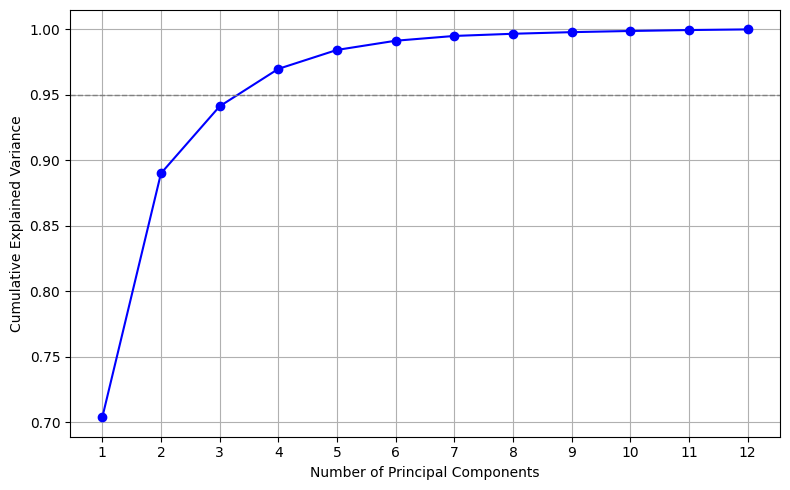

Optimal number of components to retain 95% variance: 4


In [59]:
n_optimal = plot_pca_variance(X, n_components=X.shape[1], threshold=0.95)

In [60]:
import time
from pathlib import Path
from datetime import datetime

all_best = []  # collects best_result from every model
_iter_t0 = None

# Logger setup
log_dir = Path("./results/logs/gs/classical/best_param")
log_dir.mkdir(parents=True, exist_ok=True)

_current_log_path = None

def setup_logger(name):
  """Panggil di awal tiap section. name contoh: 'svc_linear', 'xgb_gbtree'."""
  global _current_log_path
  _current_log_path = log_dir / f"{name}.log"
  # truncate file kalau sudah ada, biar tiap run fresh
  _current_log_path.write_text("")
  log(f"📝 Log: {_current_log_path}")
  log(f"🕒 Started: {datetime.now().isoformat(timespec='seconds')}")

def log(msg=""):
  """Print ke console dan append ke file log section aktif."""
  print(msg)
  if _current_log_path is not None:
    with open(_current_log_path, "a", encoding="utf-8") as f:
      f.write(str(msg) + "\n")


# 1. SVC

## 1.1 Linear

In [61]:
# Search Space Configuration
import numpy as np

search_space = {
  'C': [10],
  'class_weight': [None],
  'tol': [0.1]
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [62]:
setup_logger("svc_linear")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from utils.hpo import get_search_space
from skopt import BayesSearchCV
from sklearn.decomposition import PCA
from model.models import svc_model
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

best_score = -np.inf
best_result = None
results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())
  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()
  

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('svc', SVC(
        kernel='linear',
        probability=True,
        random_state=42, 
        decision_function_shape='ovr',
        **params
      ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

    
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'execution_time': iter_time,
    }

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']:.4f} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

📝 Log: results\logs\gs\classical\best_param\svc_linear.log
🕒 Started: 2026-05-22T09:29:21
🔬 Search space: 1 C × 1 class_weight × 1 tol =  1 configs × 5 folds = 5 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3

  ▶ [1/1] C=10 | class_weight=None | tol=0.1
    F1 → Acc=0.4395 | Prec=0.2972 | Rec=0.4395 | F1=0.3278 | AUROC=0.6963 | PRAUC=0.4676
    F2 → Acc=0.4491 | Prec=0.2844 | Rec=0.4491 | F1=0.3317 | AUROC=0.7218 | PRAUC=0.5031
    F3 → Acc=0.4467 | Prec=0.2814 | Rec=0.4467 | F1=0.3295 | AUROC=0.6872 | PRAUC=0.4567
    F4 → Acc=0.4376 | Prec=0.2856 | Rec=0.4376 | F1=0.3183 | AUROC=0.7064 | PRAUC=0.4850
    F5 → Acc=0.4407 | Prec=0.2785 | Rec=0.4407 | F1=0.3253 | AUROC=0.6935 | PRAUC=0.4588
  ✅  Acc:0.4427±0.0044 | Precision:0.2854±0.0064  |Recall:0.4427±0.0044 |F1:0.3265±0.0046 | AUROC:0.7010±0.0121 | PRAUC:0.4742±0.0176 | MCC:0.0688 | Composite:0.5393

🏆 Best config : C=10 | class_weight=None | tol=0.1
   Composite   : 0.5393 (AUROC=0.7010±0.0121 | PRAUC=0.4742±0.0176 | Ac

In [63]:
import pandas as pd
import os

dirpath = "./results/best_param/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + "svc_linear.csv"
df.to_csv(filename, index=False)

log(f"✅ Saved: {filename}")

✅ Saved: ./results/best_param/svc_linear.csv


In [64]:
# ── Collect best result ──
best_result['model'] = "SVC Linear"
all_best.append(dict(best_result))
log(f"✅ [SVC Linear] recorded | Exec. time: {best_result['execution_time']:.1f}s")

✅ [SVC Linear] recorded | Exec. time: 226.1s


## 1.2 Poly

In [65]:
# Search Space Configuration
import numpy as np

search_space = {
  'C': [1],
  'class_weight': [None],
  'tol': [0.1],
  'degree': [5],
  'gamma': [0.5],
  'coef0': [3],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [66]:
setup_logger("svc_poly")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from utils.hpo import get_search_space
from skopt import BayesSearchCV
from sklearn.decomposition import PCA
from model.models import svc_model
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

best_score = -np.inf
best_result = None
results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())
  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()
  
  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('svc', SVC(kernel='poly', probability=True, random_state=42, **params))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

     
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'execution_time': iter_time,
    }

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']:.4f} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

📝 Log: results\logs\gs\classical\best_param\svc_poly.log
🕒 Started: 2026-05-22T09:33:07
🔬 Search space: 1 C × 1 class_weight × 1 tol × 1 degree × 1 gamma × 1 coef0 =  1 configs × 5 folds = 5 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3

  ▶ [1/1] C=1 | class_weight=None | tol=0.1 | degree=5 | gamma=0.5 | coef0=3
    F1 → Acc=0.9721 | Prec=0.9726 | Rec=0.9721 | F1=0.9723 | AUROC=0.9988 | PRAUC=0.9958
    F2 → Acc=0.9741 | Prec=0.9743 | Rec=0.9741 | F1=0.9741 | AUROC=0.9984 | PRAUC=0.9957
    F3 → Acc=0.9621 | Prec=0.9623 | Rec=0.9621 | F1=0.9621 | AUROC=0.9976 | PRAUC=0.9935
    F4 → Acc=0.9721 | Prec=0.9728 | Rec=0.9721 | F1=0.9723 | AUROC=0.9986 | PRAUC=0.9960
    F5 → Acc=0.9625 | Prec=0.9634 | Rec=0.9625 | F1=0.9627 | AUROC=0.9982 | PRAUC=0.9941
  ✅  Acc:0.9686±0.0052 | Precision:0.9691±0.0051  |Recall:0.9686±0.0052 |F1:0.9687±0.0052 | AUROC:0.9983±0.0004 | PRAUC:0.9950±0.0010 | MCC:0.9550 | Composite:0.9873

🏆 Best config : C=1 | class_weight=None | tol=0.1 | degree=5 

In [67]:
import pandas as pd
import os

dirpath = "./results/best_param/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + "svc_poly.csv"
df.to_csv(filename, index=False)

print(f"✅ Saved: {filename}")

✅ Saved: ./results/best_param/svc_poly.csv


In [68]:
# ── Collect best result ──
best_result['model'] = "SVC Poly"
all_best.append(dict(best_result))
log(f"✅ [SVC Poly] recorded | Exec. time: {best_result['execution_time']:.1f}s")

✅ [SVC Poly] recorded | Exec. time: 72.2s


## 1.3 RBF

In [69]:
# Search Space Configuration
import numpy as np

search_space = {
  'C': [10],
  'class_weight': [None],
  'decision_function_shape': ['ovr'],
  'tol': [0.1],
  'gamma': [0.5],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [70]:
setup_logger("svc_rbf")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from utils.hpo import get_search_space
from skopt import BayesSearchCV
from sklearn.decomposition import PCA
from model.models import svc_model
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

best_score = -np.inf
best_result = None
results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())
  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()
  
  
  log(f"\n  ▶ {tag}")
  _iter_t0 = time.perf_counter()

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('svc', SVC(kernel='rbf', probability=True, random_state=42, **params))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

     
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'execution_time': iter_time,
    }

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']:.4f} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

📝 Log: results\logs\gs\classical\best_param\svc_rbf.log
🕒 Started: 2026-05-22T09:34:19
🔬 Search space: 1 C × 1 class_weight × 1 decision_function_shape × 1 tol × 1 gamma =  1 configs × 5 folds = 5 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3

  ▶ [1/1] C=10 | class_weight=None | decision_function_shape=ovr | tol=0.1 | gamma=0.5

  ▶ C=10 | class_weight=None | decision_function_shape=ovr | tol=0.1 | gamma=0.5
    F1 → Acc=0.9784 | Prec=0.9788 | Rec=0.9784 | F1=0.9785 | AUROC=0.9993 | PRAUC=0.9973
    F2 → Acc=0.9745 | Prec=0.9749 | Rec=0.9745 | F1=0.9746 | AUROC=0.9984 | PRAUC=0.9953
    F3 → Acc=0.9712 | Prec=0.9715 | Rec=0.9712 | F1=0.9713 | AUROC=0.9981 | PRAUC=0.9943
    F4 → Acc=0.9817 | Prec=0.9819 | Rec=0.9817 | F1=0.9818 | AUROC=0.9992 | PRAUC=0.9970
    F5 → Acc=0.9702 | Prec=0.9707 | Rec=0.9702 | F1=0.9703 | AUROC=0.9983 | PRAUC=0.9941
  ✅  Acc:0.9752±0.0043 | Precision:0.9756±0.0042  |Recall:0.9752±0.0043 |F1:0.9753±0.0043 | AUROC:0.9986±0.0005 | PRAUC:0.9956±0.0

In [71]:
import pandas as pd
import os

dirpath = "./results/best_param/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + "svc_rbf.csv"
df.to_csv(filename, index=False)

print(f"✅ Saved: {filename}")

✅ Saved: ./results/best_param/svc_rbf.csv


In [72]:
# ── Collect best result ──
best_result['model'] = "SVC RBF"
all_best.append(dict(best_result))
log(f"✅ [SVC RBF] recorded | Exec. time: {best_result['execution_time']:.1f}s")

✅ [SVC RBF] recorded | Exec. time: 10.6s


## 1.4 Sigmoid

In [73]:
# Search Space Configuration
import numpy as np

search_space = {
  'C': [1],
  'class_weight': [None],
  'decision_function_shape': ['ovr'],
  'tol': [0.1],
  'gamma': [0.01],
  'coef0': [0],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [74]:
setup_logger("svc_sigmoid")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from utils.hpo import get_search_space
from skopt import BayesSearchCV
from sklearn.decomposition import PCA
from model.models import svc_model
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

best_score = -np.inf
best_result = None
results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())
  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()
  
  
  log(f"\n  ▶ {tag}")
  _iter_t0 = time.perf_counter()

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('svc', SVC(kernel='sigmoid', probability=True, random_state=42, **params))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

     
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'execution_time': iter_time,
    }

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']:.4f} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

📝 Log: results\logs\gs\classical\best_param\svc_sigmoid.log
🕒 Started: 2026-05-22T09:34:30
🔬 Search space: 1 C × 1 class_weight × 1 decision_function_shape × 1 tol × 1 gamma × 1 coef0 =  1 configs × 5 folds = 5 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3

  ▶ [1/1] C=1 | class_weight=None | decision_function_shape=ovr | tol=0.1 | gamma=0.01 | coef0=0

  ▶ C=1 | class_weight=None | decision_function_shape=ovr | tol=0.1 | gamma=0.01 | coef0=0
    F1 → Acc=0.4505 | Prec=0.3070 | Rec=0.4505 | F1=0.3551 | AUROC=0.6588 | PRAUC=0.4058
    F2 → Acc=0.4457 | Prec=0.3033 | Rec=0.4457 | F1=0.3539 | AUROC=0.6736 | PRAUC=0.4335
    F3 → Acc=0.4539 | Prec=0.3050 | Rec=0.4539 | F1=0.3608 | AUROC=0.6574 | PRAUC=0.4072
    F4 → Acc=0.4500 | Prec=0.3073 | Rec=0.4500 | F1=0.3544 | AUROC=0.6648 | PRAUC=0.4166
    F5 → Acc=0.4368 | Prec=0.2892 | Rec=0.4368 | F1=0.3436 | AUROC=0.6721 | PRAUC=0.4238
  ✅  Acc:0.4474±0.0059 | Precision:0.3024±0.0068  |Recall:0.4474±0.0059 |F1:0.3536±0.0056 | AURO

In [75]:
import pandas as pd
import os

dirpath = "./results/best_param/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + "svc_rbf.csv"
df.to_csv(filename, index=False)

print(f"✅ Saved: {filename}")

✅ Saved: ./results/best_param/svc_rbf.csv


In [76]:
# ── Collect best result ──
best_result['model'] = "SVC Sigmoid"
all_best.append(dict(best_result))
log(f"✅ [SVC Sigmoid] recorded | Exec. time: {best_result['execution_time']:.1f}s")

✅ [SVC Sigmoid] recorded | Exec. time: 75.7s


# 2. XGBoost

## 2.1 GBTree

In [77]:
# Search Space Configuration
import numpy as np

# search_space = {
#   'n_estimators': [1000],
#   'learning_rate': [0.01],
#   'max_depth': [10],
#   'subsample': [0.5],
#   'colsample_bytree': [1],
# }

search_space = {
  'n_estimators': [100],
  'learning_rate': [0.1],
  'max_depth': [10],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [78]:
setup_logger("xgb_gbtree")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.decomposition import PCA
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

best_score = -np.inf
best_result = None
results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())
  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()
  
  
  log(f"\n  ▶ {tag}")
  _iter_t0 = time.perf_counter()

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('xgb', XGBClassifier(
        booster='gbtree', objective='multi:softprob', random_state=42, device='cuda', **params
      ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'execution_time': iter_time,
    }

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']:.4f} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

📝 Log: results\logs\gs\classical\best_param\xgb_gbtree.log
🕒 Started: 2026-05-22T09:35:46
🔬 Search space: 1 n_estimators × 1 learning_rate × 1 max_depth =  1 configs × 5 folds = 5 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3

  ▶ [1/1] n_estimators=100 | learning_rate=0.1 | max_depth=10

  ▶ n_estimators=100 | learning_rate=0.1 | max_depth=10
    F1 → Acc=0.9731 | Prec=0.9731 | Rec=0.9731 | F1=0.9731 | AUROC=0.9991 | PRAUC=0.9971
    F2 → Acc=0.9726 | Prec=0.9728 | Rec=0.9726 | F1=0.9727 | AUROC=0.9990 | PRAUC=0.9973
    F3 → Acc=0.9673 | Prec=0.9675 | Rec=0.9673 | F1=0.9674 | AUROC=0.9983 | PRAUC=0.9941
    F4 → Acc=0.9765 | Prec=0.9765 | Rec=0.9765 | F1=0.9765 | AUROC=0.9994 | PRAUC=0.9980
    F5 → Acc=0.9640 | Prec=0.9641 | Rec=0.9640 | F1=0.9640 | AUROC=0.9983 | PRAUC=0.9939
  ✅  Acc:0.9707±0.0045 | Precision:0.9708±0.0044  |Recall:0.9707±0.0045 |F1:0.9707±0.0044 | AUROC:0.9988±0.0004 | PRAUC:0.9961±0.0017 | MCC:0.9578 | Composite:0.9885

🏆 Best config : n_estimators=1

In [79]:
import pandas as pd
import os

dirpath = "./results/best_param/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + "xgb_gbtree.csv"
df.to_csv(filename, index=False)

print(f"✅ Saved: {filename}")

✅ Saved: ./results/best_param/xgb_gbtree.csv


In [80]:
# ── Collect best result ──
best_result['model'] = "XGBoost GBTree"
all_best.append(dict(best_result))
log(f"✅ [XGBoost GBTree] recorded | Exec. time: {best_result['execution_time']:.1f}s")

✅ [XGBoost GBTree] recorded | Exec. time: 13.0s


## 2.2 Dart

In [81]:
# Search Space Configuration
import numpy as np

# search_space = {
#   'n_estimators': [1000],
#   'learning_rate': [0.01],
#   'max_depth': [10],
#   'subsample': [0.5],
#   'colsample_bytree': [1],

#   'rate_drop': [0],
# }

search_space = {
  'n_estimators': [100],
  'learning_rate': [0.1],
  'max_depth': [10],
  'rate_drop': [0.1],
  'skip_drop': [0.5],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [82]:
setup_logger("xgb_dart")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.decomposition import PCA
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

best_score = -np.inf
best_result = None
results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())
  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()
  
  
  log(f"\n  ▶ {tag}")
  _iter_t0 = time.perf_counter()

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('xgb', XGBClassifier(
        booster='dart', objective='multi:softprob', random_state=42, device='cuda', **params
      ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'execution_time': iter_time,
    }

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']:.4f} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

📝 Log: results\logs\gs\classical\best_param\xgb_dart.log
🕒 Started: 2026-05-22T09:35:59
🔬 Search space: 1 n_estimators × 1 learning_rate × 1 max_depth × 1 rate_drop × 1 skip_drop =  1 configs × 5 folds = 5 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3

  ▶ [1/1] n_estimators=100 | learning_rate=0.1 | max_depth=10 | rate_drop=0.1 | skip_drop=0.5

  ▶ n_estimators=100 | learning_rate=0.1 | max_depth=10 | rate_drop=0.1 | skip_drop=0.5
    F1 → Acc=0.9707 | Prec=0.9707 | Rec=0.9707 | F1=0.9707 | AUROC=0.9989 | PRAUC=0.9966
    F2 → Acc=0.9707 | Prec=0.9709 | Rec=0.9707 | F1=0.9707 | AUROC=0.9988 | PRAUC=0.9967
    F3 → Acc=0.9621 | Prec=0.9624 | Rec=0.9621 | F1=0.9622 | AUROC=0.9981 | PRAUC=0.9937
    F4 → Acc=0.9750 | Prec=0.9750 | Rec=0.9750 | F1=0.9750 | AUROC=0.9991 | PRAUC=0.9975
    F5 → Acc=0.9601 | Prec=0.9602 | Rec=0.9601 | F1=0.9601 | AUROC=0.9980 | PRAUC=0.9927
  ✅  Acc:0.9677±0.0057 | Precision:0.9678±0.0056  |Recall:0.9677±0.0057 |F1:0.9677±0.0057 | AUROC:0.9986±0.

In [83]:
import pandas as pd
import os

dirpath = "./results/best_param/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + "xgb_dart.csv"
df.to_csv(filename, index=False)

print(f"✅ Saved: {filename}")

✅ Saved: ./results/best_param/xgb_dart.csv


In [84]:
# ── Collect best result ──
best_result['model'] = "XGBoost Dart"
all_best.append(dict(best_result))
log(f"✅ [XGBoost Dart] recorded | Exec. time: {best_result['execution_time']:.1f}s")

✅ [XGBoost Dart] recorded | Exec. time: 25.0s


# 3. CatBoost

In [85]:
# Search Space Configuration
import numpy as np

search_space = {
  'iterations': [500],
  'depth': [10],
  'learning_rate': [0.1],
  'l2_leaf_reg': [1],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [86]:
setup_logger("catboost")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.decomposition import PCA
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)
from catboost import CatBoostClassifier

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

best_score = -np.inf
best_result = None
results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())
  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('cat', CatBoostClassifier(
        loss_function="MultiClassOneVsAll",
        eval_metric="Accuracy",
        verbose=0,
        random_seed=42, 
        task_type="GPU",
        devices='0',
        **params
      ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)
    y_prob = y_prob / y_prob.sum(axis=1, keepdims=True)  # Normalize probabilities

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'execution_time': iter_time,
    }

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']:.4f} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

📝 Log: results\logs\gs\classical\best_param\catboost.log
🕒 Started: 2026-05-22T09:36:24
🔬 Search space: 1 iterations × 1 depth × 1 learning_rate × 1 l2_leaf_reg =  1 configs × 5 folds = 5 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3

  ▶ [1/1] iterations=500 | depth=10 | learning_rate=0.1 | l2_leaf_reg=1
    F1 → Acc=0.9803 | Prec=0.9806 | Rec=0.9803 | F1=0.9804 | AUROC=0.9994 | PRAUC=0.9980
    F2 → Acc=0.9808 | Prec=0.9808 | Rec=0.9808 | F1=0.9808 | AUROC=0.9993 | PRAUC=0.9979
    F3 → Acc=0.9726 | Prec=0.9728 | Rec=0.9726 | F1=0.9727 | AUROC=0.9990 | PRAUC=0.9967
    F4 → Acc=0.9837 | Prec=0.9837 | Rec=0.9837 | F1=0.9837 | AUROC=0.9996 | PRAUC=0.9985
    F5 → Acc=0.9697 | Prec=0.9698 | Rec=0.9697 | F1=0.9698 | AUROC=0.9985 | PRAUC=0.9951
  ✅  Acc:0.9774±0.0053 | Precision:0.9776±0.0053  |Recall:0.9774±0.0053 |F1:0.9775±0.0053 | AUROC:0.9991±0.0004 | PRAUC:0.9973±0.0012 | MCC:0.9675 | Composite:0.9913

🏆 Best config : iterations=500 | depth=10 | learning_rate=0.1 | l2_le

In [87]:
import pandas as pd
import os

dirpath = "./results/best_param/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + "catboost.csv"
df.to_csv(filename, index=False)

print(f"✅ Saved: {filename}")

✅ Saved: ./results/best_param/catboost.csv


In [88]:
# ── Collect best result ──
best_result['model'] = "CatBoost"
all_best.append(dict(best_result))
log(f"✅ [CatBoost] recorded | Exec. time: {best_result['execution_time']:.1f}s")

✅ [CatBoost] recorded | Exec. time: 73.3s


---
## 📊 Tabel Evaluasi Akhir

In [89]:
# ════════════════════════════════════════════════════════════
# 📊 TABEL EVALUASI AKHIR – Classical Models
# ════════════════════════════════════════════════════════════
import pandas as pd

def build_eval_table(all_best):
    rows = []
    for r in all_best:
        params_str = ' | '.join(f'{k}={v}' for k, v in r.get('params', {}).items())
        rows.append({
            'Model'          : r['model'],
            'Accuracy'       : r['acc'],
            'Precision'      : r['prec'],
            'Recall'         : r['rec'],
            'F1-Score'       : r['f1'],
            'ROC-AUC'        : r['roc'],
            'PR-AUC'         : r['pra'],
            'Exec. Time (s)' : round(r['execution_time'], 2) if 'execution_time' in r else 'N/A',
            'Best Params'    : params_str,
        })
    df = pd.DataFrame(rows)
    df = df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
    df.index += 1
    return df

pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.4f}'.format)

eval_df = build_eval_table(all_best)
display(eval_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Exec. Time (s),Best Params
1,CatBoost,0.9774±0.0053,0.9776±0.0053,0.9774±0.0053,0.9775±0.0053,0.9991±0.0004,0.9973±0.0012,73.3400,iterations=500 | depth=10 | learning_rate=0.1 | l2_leaf_reg=1
2,XGBoost GBTree,0.9707±0.0045,0.9708±0.0044,0.9707±0.0045,0.9707±0.0044,0.9988±0.0004,0.9961±0.0017,12.9700,n_estimators=100 | learning_rate=0.1 | max_depth=10
3,SVC RBF,0.9752±0.0043,0.9756±0.0042,0.9752±0.0043,0.9753±0.0043,0.9986±0.0005,0.9956±0.0013,10.6000,C=10 | class_weight=None | decision_function_shape=ovr | tol=0.1 | gamma=0.5
4,XGBoost Dart,0.9677±0.0057,0.9678±0.0056,0.9677±0.0057,0.9677±0.0057,0.9986±0.0005,0.9954±0.0019,25.0500,n_estimators=100 | learning_rate=0.1 | max_depth=10 | rate_drop=0.1 | skip_drop=0.5
5,SVC Poly,0.9686±0.0052,0.9691±0.0051,0.9686±0.0052,0.9687±0.0052,0.9983±0.0004,0.9950±0.0010,72.1900,C=1 | class_weight=None | tol=0.1 | degree=5 | gamma=0.5 | coef0=3
6,SVC Linear,0.4427±0.0044,0.2854±0.0064,0.4427±0.0044,0.3265±0.0046,0.7010±0.0121,0.4742±0.0176,226.0800,C=10 | class_weight=None | tol=0.1
7,SVC Sigmoid,0.4474±0.0059,0.3024±0.0068,0.4474±0.0059,0.3536±0.0056,0.6653±0.0066,0.4174±0.0104,75.7400,C=1 | class_weight=None | decision_function_shape=ovr | tol=0.1 | gamma=0.01 | coef0=0


CatBoost terakhir dengan waktu eksekusi 168.8900 merupakan `loss_function="Multiclass"`, sedangkan dua sisanya adalah `loss_function="MulticlassOneVsAll"`

In [90]:
import os
os.makedirs('./results', exist_ok=True)
eval_df.to_csv('./results/eval_classical_final.csv', index=True)
print('✅ Saved: ./results/eval_classical_final.csv')

✅ Saved: ./results/eval_classical_final.csv
